<h3><b>Modelling Random Forest</b><br>Classification Detection Webshell on PHP Code based on Extraction Features</h3>

In [11]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_curve, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, cross_val_score, learning_curve
import joblib


In [12]:
#import dataset
df = pd.read_csv('php_features_dataset.csv')
df.head()

,evalArgSuperglobal,dangerFuncArgSuperglobal,decodeFuncArgToSink,decodeFuncCount,maxDecodeChainDepth,dynamicFuncCallExists,dynamicIncExists,varExists,classDefExists,funcDefCount,...,lex_symbol_count,stat_entropy,stat_length,stat_unique_char_ratio,stat_digit_ratio,stat_symbol_ratio,stat_longest_string,stat_compression_ratio,filepath,label
0,NaN,NaN,NaN,0,0,NaN,NaN,NaN,1.0,2,...,131,4.607249,1473,0.037339,0.001358,0.456212,23,0.310251,./Cleaned-Dataset/Normal/0001_01_01_000000_cre...,normal
1,NaN,NaN,NaN,0,0,NaN,NaN,NaN,1.0,2,...,64,4.656110,849,0.061249,0.000000,0.439340,13,0.368669,./Cleaned-Dataset/Normal/0001_01_01_000001_cre...,normal
2,NaN,NaN,NaN,0,0,NaN,NaN,NaN,1.0,2,...,159,4.555513,1812,0.029801,0.000000,0.461921,16,0.276490,./Cleaned-Dataset/Normal/0001_01_01_000002_cre...,normal
3,NaN,NaN,NaN,0,0,NaN,NaN,NaN,1.0,4,...,98,4.724089,2627,0.027027,0.005329,0.339931,45,0.396650,./Cleaned-Dataset/Normal/000202d76b7e71c1a3708...,normal
4,NaN,NaN,NaN,0,0,NaN,NaN,NaN,1.0,64,...,6135,4.511904,95456,0.000953,0.012529,0.545372,80,0.124550,./Cleaned-Dataset/Normal/002965d250fde3bda78ea...,normal


<h2><b>Data Cleaning</b></h2>

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7907 entries, 0 to 7906
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   evalArgSuperglobal        226 non-null    float64
 1   dangerFuncArgSuperglobal  200 non-null    float64
 2   decodeFuncArgToSink       4 non-null      float64
 3   decodeFuncCount           7907 non-null   int64  
 4   maxDecodeChainDepth       7907 non-null   int64  
 5   dynamicFuncCallExists     1094 non-null   float64
 6   dynamicIncExists          919 non-null    float64
 7   varExists                 355 non-null    float64
 8   classDefExists            2841 non-null   float64
 9   funcDefCount              7907 non-null   int64  
 10  superglobalAsFuncArg      7907 non-null   int64  
 11  superglobalInAsgn         7907 non-null   int64  
 12  ast_parse_error           7907 non-null   int64  
 13  lex_func_eval             7907 non-null   int64  
 14  lex_func

<p>berdasarkan informasi diatas diketahui bahwa terdapat beberapa fitur yang didalamnya mengandung nilai null, hal ini dapa diketahui dengan jumlah nilai non-null yang tidak seragam</p>

In [14]:
df.isnull().sum()

evalArgSuperglobal          7681
dangerFuncArgSuperglobal    7707
decodeFuncArgToSink         7903
decodeFuncCount                0
maxDecodeChainDepth            0
dynamicFuncCallExists       6813
dynamicIncExists            6988
varExists                   7552
classDefExists              5066
funcDefCount                   0
superglobalAsFuncArg           0
superglobalInAsgn              0
ast_parse_error                0
lex_func_eval                  0
lex_func_assert                0
lex_func_system                0
lex_func_exec                  0
lex_func_shell_exec            0
lex_func_passthru              0
lex_func_popen                 0
lex_func_proc_open             0
lex_obfus_base64_decode        0
lex_obfus_gzinflate            0
lex_obfus_gzuncompress         0
lex_obfus_str_rot13            0
lex_input__GET                 0
lex_input__POST                0
lex_input__REQUEST             0
lex_input__COOKIE              0
lex_input__FILES               0
lex_includ

<p>terdapat 7 fitur yang mengandung nilai null, hal ini perlu diatasi guna menciptakan model yang lebih baik</p>

In [15]:
df = df.fillna(0)
df.isnull().sum()

evalArgSuperglobal          0
dangerFuncArgSuperglobal    0
decodeFuncArgToSink         0
decodeFuncCount             0
maxDecodeChainDepth         0
dynamicFuncCallExists       0
dynamicIncExists            0
varExists                   0
classDefExists              0
funcDefCount                0
superglobalAsFuncArg        0
superglobalInAsgn           0
ast_parse_error             0
lex_func_eval               0
lex_func_assert             0
lex_func_system             0
lex_func_exec               0
lex_func_shell_exec         0
lex_func_passthru           0
lex_func_popen              0
lex_func_proc_open          0
lex_obfus_base64_decode     0
lex_obfus_gzinflate         0
lex_obfus_gzuncompress      0
lex_obfus_str_rot13         0
lex_input__GET              0
lex_input__POST             0
lex_input__REQUEST          0
lex_input__COOKIE           0
lex_input__FILES            0
lex_include_include         0
lex_include_include_once    0
lex_include_require         0
lex_includ

In [16]:
df["label"] = df["label"].map({"webshell": 1, "normal": 0})
df["label"].unique()

array([0, 1])

In [17]:
df = df.drop(columns=["filepath"])
print(df.columns)

Index(['evalArgSuperglobal', 'dangerFuncArgSuperglobal', 'decodeFuncArgToSink',
       'decodeFuncCount', 'maxDecodeChainDepth', 'dynamicFuncCallExists',
       'dynamicIncExists', 'varExists', 'classDefExists', 'funcDefCount',
       'superglobalAsFuncArg', 'superglobalInAsgn', 'ast_parse_error',
       'lex_func_eval', 'lex_func_assert', 'lex_func_system', 'lex_func_exec',
       'lex_func_shell_exec', 'lex_func_passthru', 'lex_func_popen',
       'lex_func_proc_open', 'lex_obfus_base64_decode', 'lex_obfus_gzinflate',
       'lex_obfus_gzuncompress', 'lex_obfus_str_rot13', 'lex_input__GET',
       'lex_input__POST', 'lex_input__REQUEST', 'lex_input__COOKIE',
       'lex_input__FILES', 'lex_include_include', 'lex_include_include_once',
       'lex_include_require', 'lex_include_require_once',
       'lex_string_literal_count', 'lex_symbol_count', 'stat_entropy',
       'stat_length', 'stat_unique_char_ratio', 'stat_digit_ratio',
       'stat_symbol_ratio', 'stat_longest_string', 'stat

<h2><b>Exploratory Data Analysis</b></h2>

In [18]:
#dimensions of the dataset
df.shape

(7907, 44)

<p>dataset terdiri dari total 45 kolom dengan 7907 data yang tersedia</p>

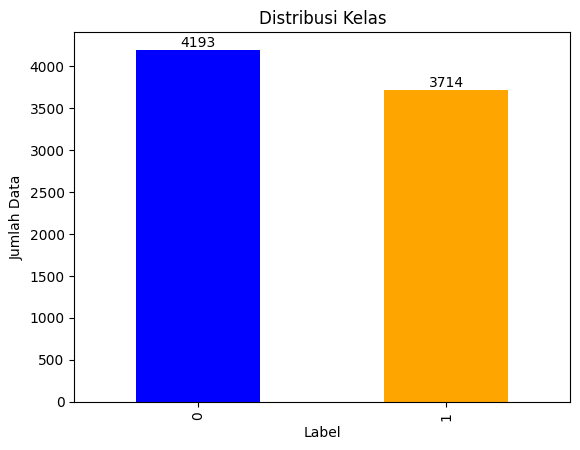

In [19]:
#visualization of class distribution
counts = df["label"].value_counts()

ax = counts.plot(kind="bar", color=["blue", "orange"])

for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.title("Distribusi Kelas")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")
plt.show()

<p>dataset yang digunakan terdiri dari 2 label yang terbagi menjadi 4193 data berlabel normal dan 3714 data berlabel webshell</p>

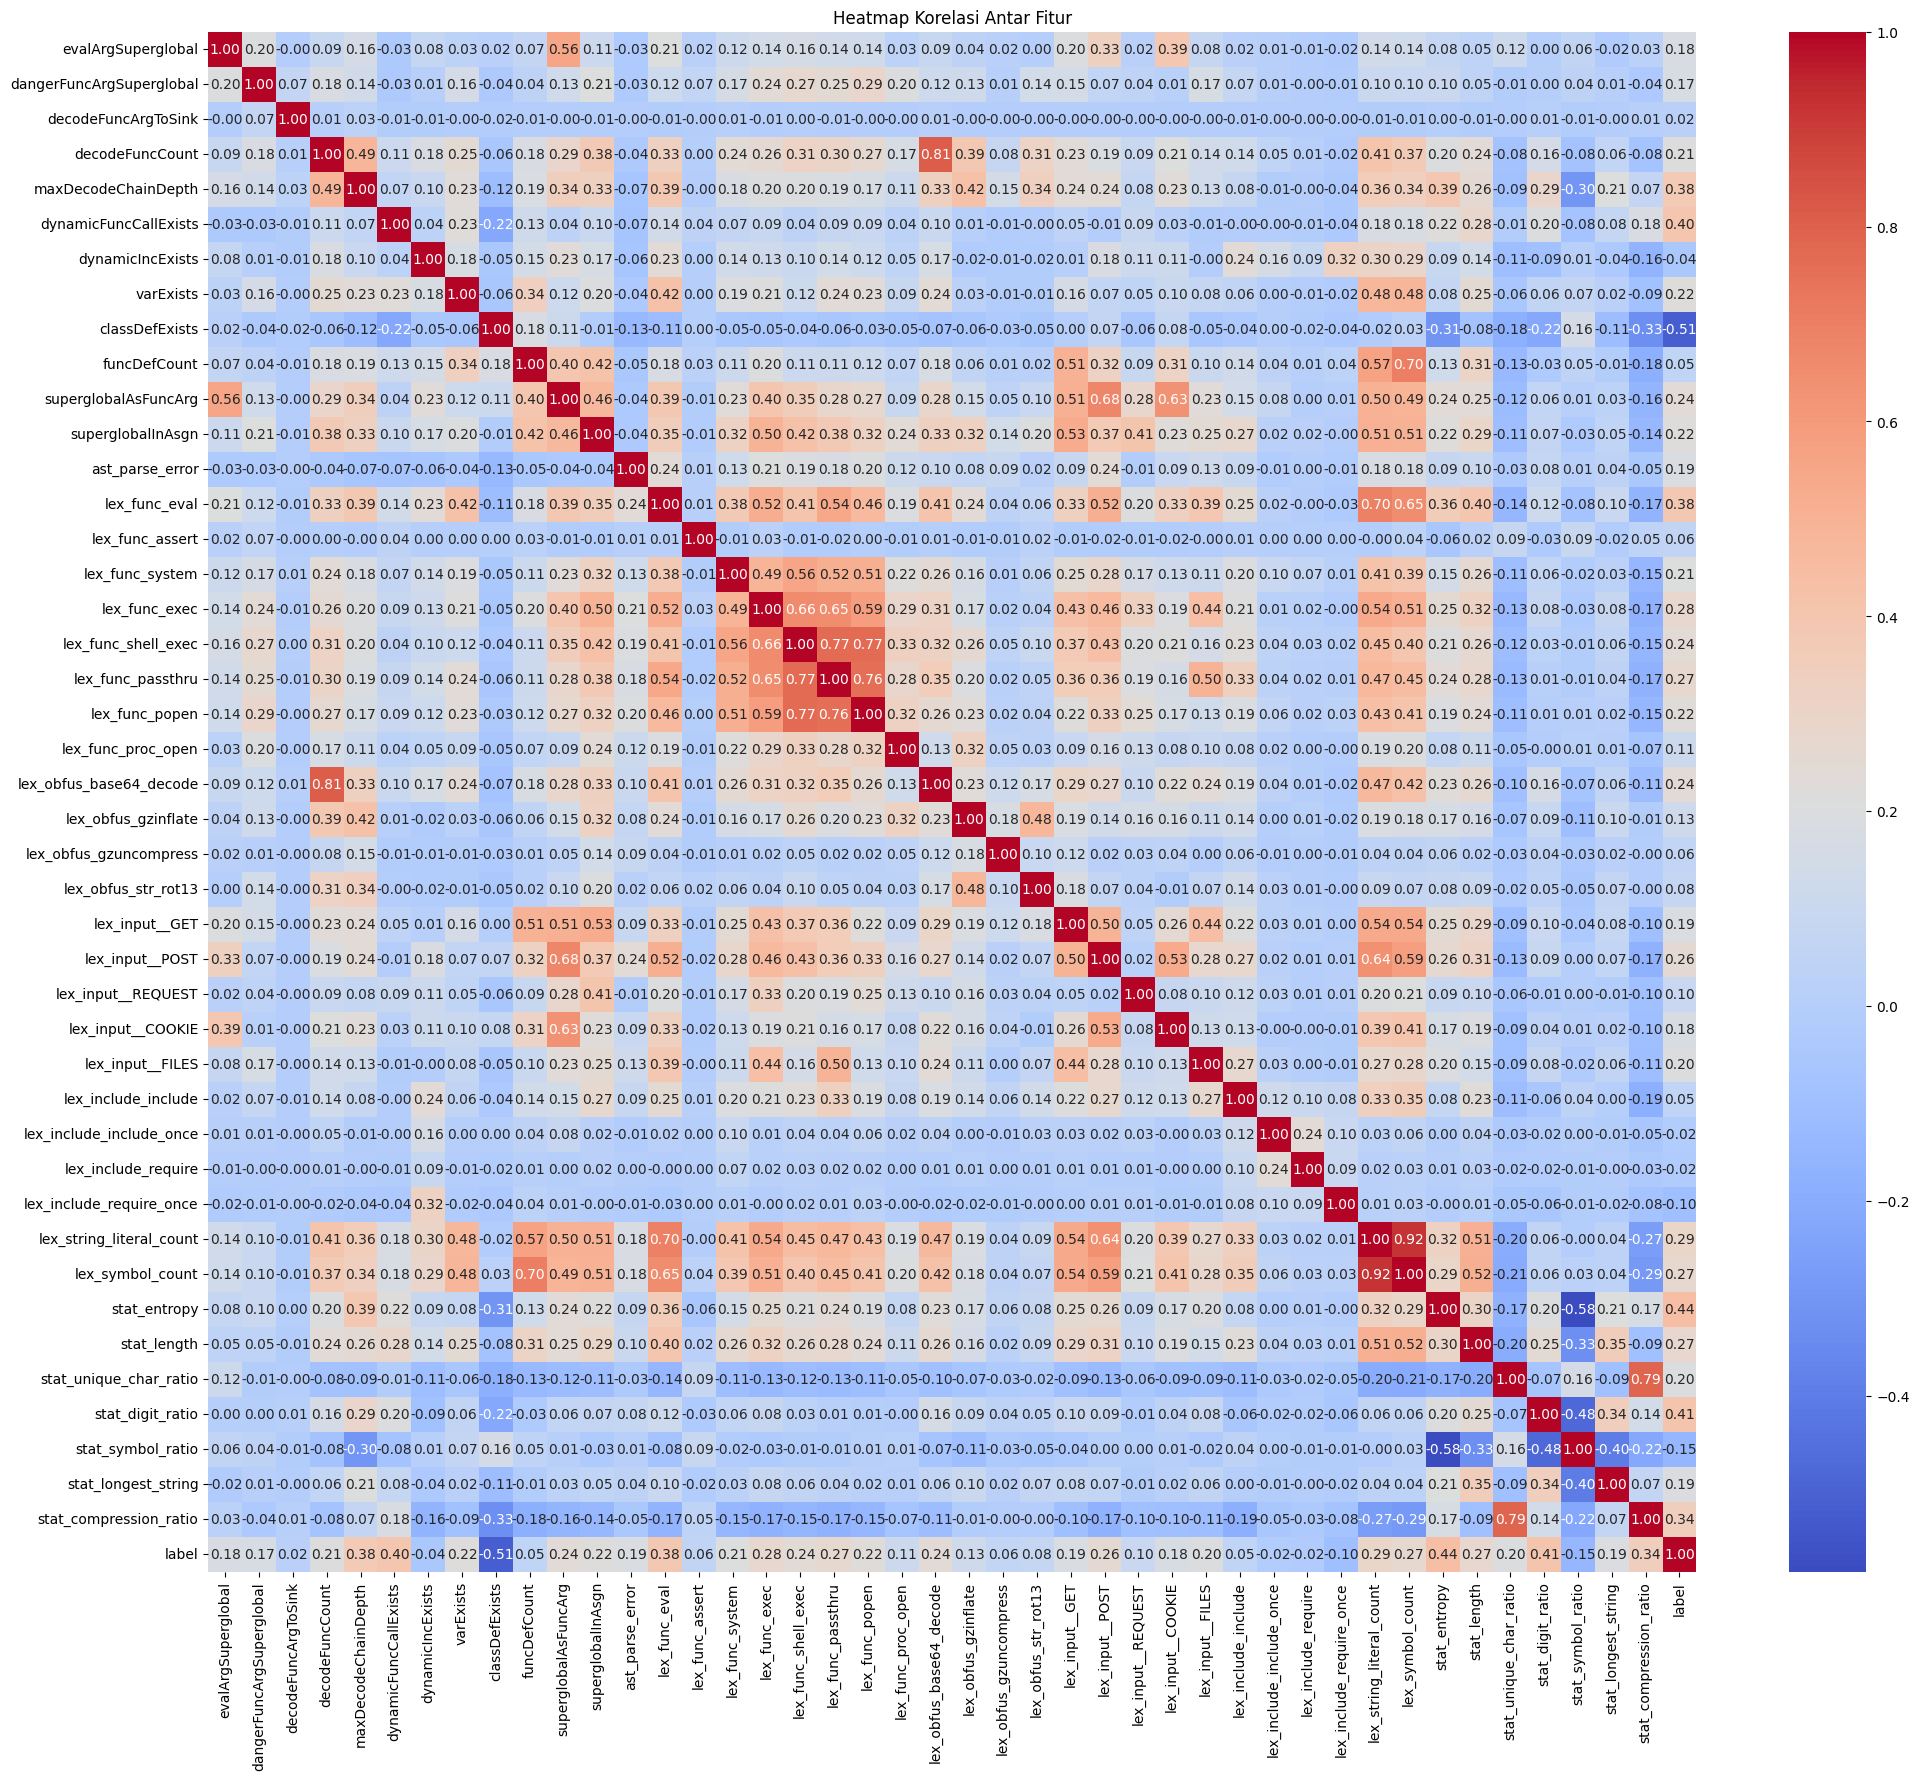

In [20]:
# Menghitung matriks korelasi
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

In [22]:
#correlation with label
corr_label = df.corr()["label"].sort_values(ascending=False)
print(corr_label)

label                       1.000000
stat_entropy                0.442796
stat_digit_ratio            0.411217
dynamicFuncCallExists       0.397887
lex_func_eval               0.384268
maxDecodeChainDepth         0.376029
stat_compression_ratio      0.342266
lex_string_literal_count    0.293501
lex_func_exec               0.275702
stat_length                 0.274667
lex_symbol_count            0.267748
lex_func_passthru           0.266944
lex_input__POST             0.257724
lex_func_shell_exec         0.244176
superglobalAsFuncArg        0.239562
lex_obfus_base64_decode     0.235840
lex_func_popen              0.224098
superglobalInAsgn           0.218222
varExists                   0.216908
decodeFuncCount             0.211402
lex_func_system             0.207376
stat_unique_char_ratio      0.202550
lex_input__FILES            0.200171
stat_longest_string         0.192641
lex_input__GET              0.188928
ast_parse_error             0.185553
evalArgSuperglobal          0.182258
l

<p>nilai korelasi yang semakin mendekati 1 memiliki hubungan linear positif yang semakin kuat, sedangkan nilai korelasi yang semakin mendekati -1 memiliki hubungan linear negatif. suatu fitur x dan y yang memiliki hubungan linear negatif berarti jika nilai fitur x naik, maka nilai fitur y akan turun begitupun sebaliknya. </br> pada hubungan korelasi, fitur stat_entropy memiliki hubungan linear positif yang paling kuat diantara fitur lain terhadap label. sedangkan fitur classDefExists memiliki hubungan linear negatif paling kuat terhadap label </p>

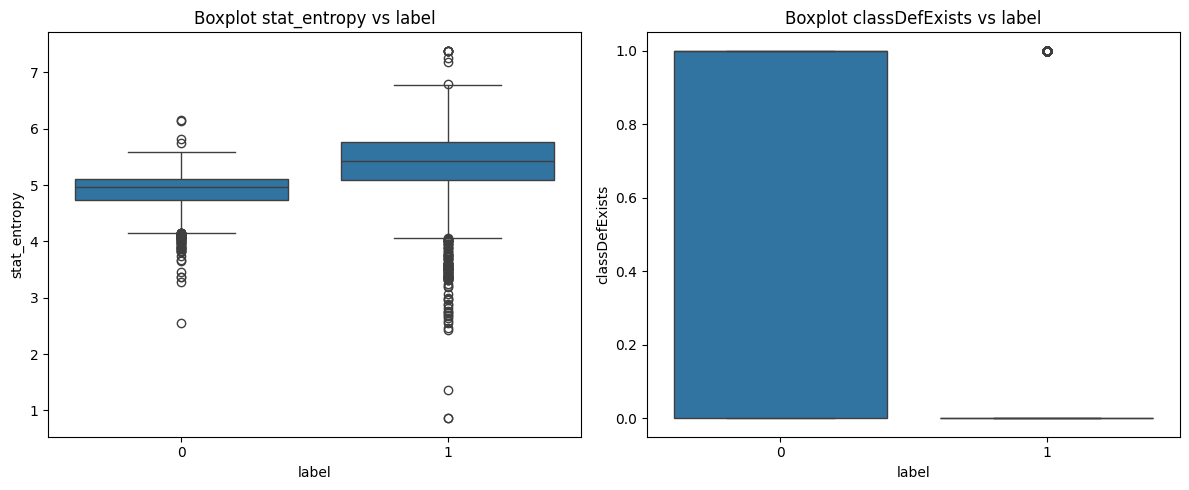

In [23]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))

sns.boxplot(x="label", y="stat_entropy", data=df, ax=ax[0])
ax[0].set_title("Boxplot stat_entropy vs label")

sns.boxplot(x="label", y="classDefExists", data=df, ax=ax[1])
ax[1].set_title("Boxplot classDefExists vs label")

plt.tight_layout()
plt.show()


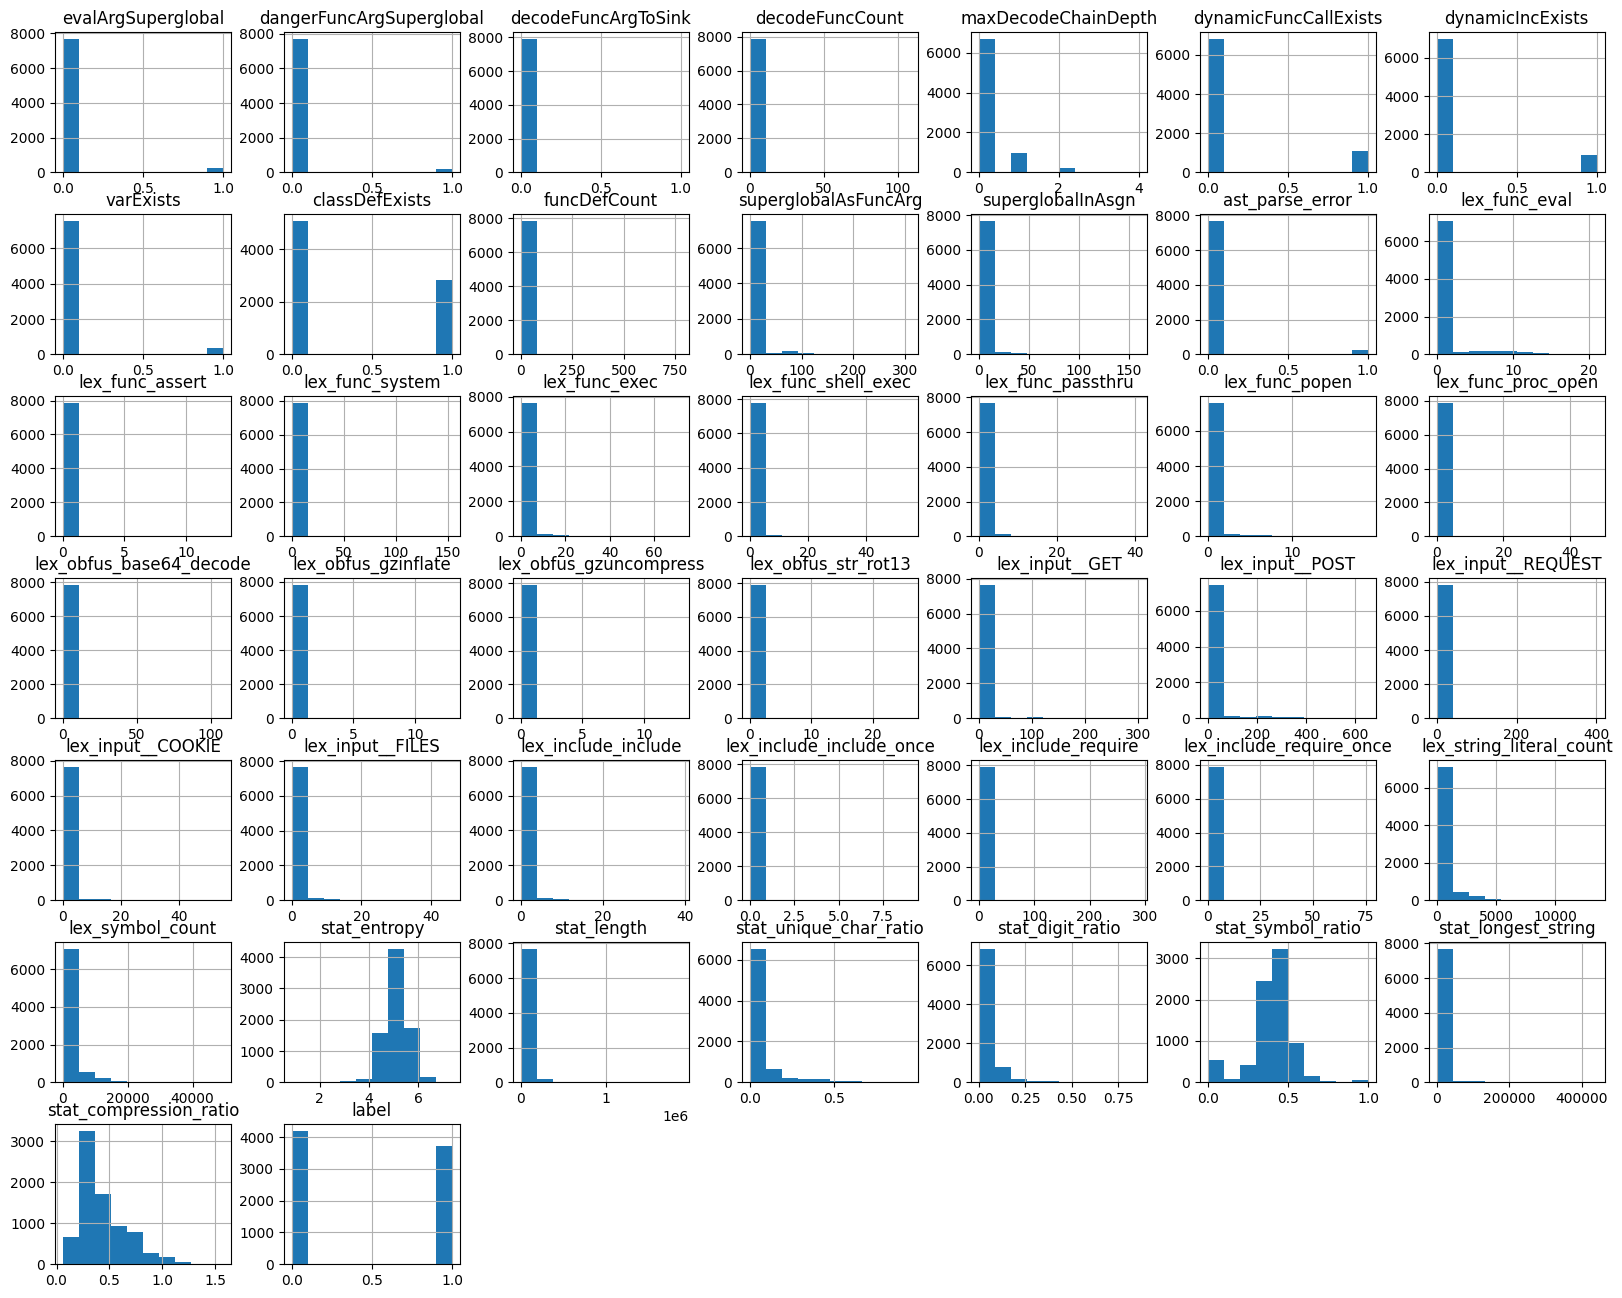

In [24]:
df.hist(figsize=(20, 16))
plt.show()

In [25]:
k = (df == 0).mean()
print(k)

evalArgSuperglobal          0.971418
dangerFuncArgSuperglobal    0.974706
decodeFuncArgToSink         0.999494
decodeFuncCount             0.846592
maxDecodeChainDepth         0.846592
dynamicFuncCallExists       0.861642
dynamicIncExists            0.883774
varExists                   0.955103
classDefExists              0.640698
funcDefCount                0.496396
superglobalAsFuncArg        0.776907
superglobalInAsgn           0.824586
ast_parse_error             0.970406
lex_func_eval               0.770709
lex_func_assert             0.976856
lex_func_system             0.825092
lex_func_exec               0.858480
lex_func_shell_exec         0.890730
lex_func_passthru           0.884659
lex_func_popen              0.905147
lex_func_proc_open          0.964841
lex_obfus_base64_decode     0.813330
lex_obfus_gzinflate         0.953459
lex_obfus_gzuncompress      0.984571
lex_obfus_str_rot13         0.984824
lex_input__GET              0.814468
lex_input__POST             0.744783
l

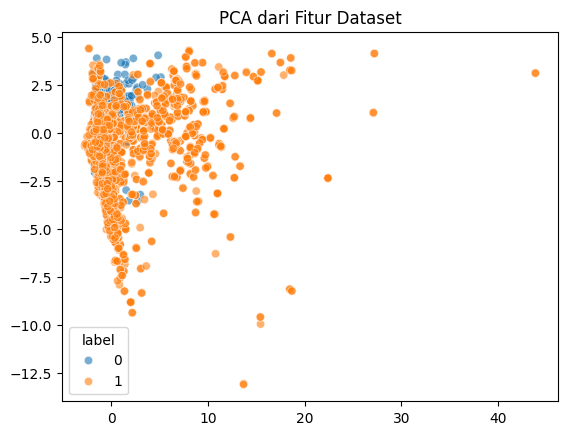

[0.20905572 0.06654258 0.05469163 0.04576814 0.04374671 0.04021163
 0.0355032  0.0318118  0.03036467 0.0278017  0.02635384 0.02454998
 0.0236571  0.0232095  0.02225882]
0.7055270168457394


In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop("label", axis=1))

pca = PCA(n_components=0.70)
xpca = pca.fit_transform(X_scaled)

sns.scatterplot(x=xpca[:,0], y=xpca[:,1], hue=df["label"], alpha=0.6)
plt.title("PCA dari Fitur Dataset")
plt.show()

print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

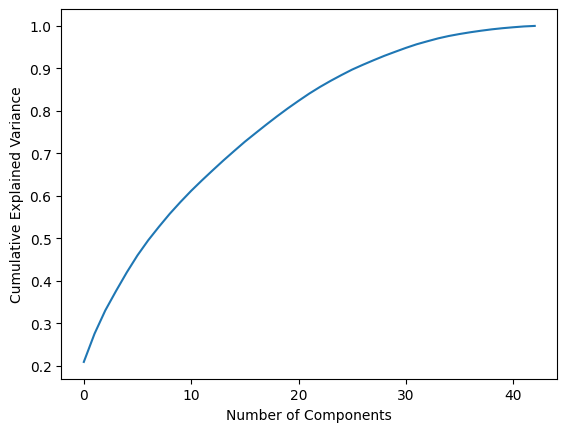

In [27]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_scaled)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

In [28]:
#skewness dan kurtosis label
stats = df["label"].agg(["skew","kurtosis"])
print(stats)

skew        0.121404
kurtosis   -1.985763
Name: label, dtype: float64


In [29]:
skewness = df.drop("label", axis=1).skew()
print(skewness)

evalArgSuperglobal           5.659355
dangerFuncArgSuperglobal     6.047713
decodeFuncArgToSink         44.435342
decodeFuncCount             20.690444
maxDecodeChainDepth          3.429706
dynamicFuncCallExists        2.095196
dynamicIncExists             2.395330
varExists                    4.396314
classDefExists               0.586603
funcDefCount                15.600026
superglobalAsFuncArg         5.633783
superglobalInAsgn            8.714337
ast_parse_error              5.552728
lex_func_eval                3.359423
lex_func_assert             20.923560
lex_func_system             21.974000
lex_func_exec                7.330836
lex_func_shell_exec         13.417151
lex_func_passthru            7.871019
lex_func_popen               7.616542
lex_func_proc_open          29.437012
lex_obfus_base64_decode     19.632843
lex_obfus_gzinflate         12.436374
lex_obfus_gzuncompress      22.758483
lex_obfus_str_rot13         29.854474
lex_input__GET               7.694341
lex_input__P

In [30]:
kurtosis = df.drop("label", axis=1).kurtosis()
print(kurtosis)

evalArgSuperglobal            30.035898
dangerFuncArgSuperglobal      34.583574
decodeFuncArgToSink         1972.998672
decodeFuncCount              669.886092
maxDecodeChainDepth           15.091808
dynamicFuncCallExists          2.390451
dynamicIncExists               3.738551
varExists                     17.331964
classDefExists                -1.656316
funcDefCount                 315.849682
superglobalAsFuncArg          38.953638
superglobalInAsgn            118.085427
ast_parse_error               28.840087
lex_func_eval                 11.506520
lex_func_assert              595.697134
lex_func_system              765.602238
lex_func_exec                 84.859286
lex_func_shell_exec          355.454196
lex_func_passthru            105.279303
lex_func_popen                73.672044
lex_func_proc_open          1238.681996
lex_obfus_base64_decode      568.219410
lex_obfus_gzinflate          192.513290
lex_obfus_gzuncompress       626.080377
lex_obfus_str_rot13         1203.983403


In [31]:
# Menghitung variansi tiap kolom numerik
variansi = df.var().sort_values()

# Urutkan dari yang terkecil
print(variansi)

decodeFuncArgToSink         5.056889e-04
stat_digit_ratio            5.321044e-03
stat_unique_char_ratio      1.539112e-02
stat_symbol_ratio           1.813458e-02
dangerFuncArgSuperglobal    2.465737e-02
evalArgSuperglobal          2.776883e-02
ast_parse_error             2.872186e-02
varExists                   4.288662e-02
stat_compression_ratio      5.112163e-02
lex_include_include_once    7.935592e-02
dynamicIncExists            1.027306e-01
dynamicFuncCallExists       1.192304e-01
lex_func_assert             1.399137e-01
lex_obfus_gzuncompress      1.633296e-01
classDefExists              2.302332e-01
label                       2.491140e-01
stat_entropy                2.603946e-01
maxDecodeChainDepth         2.723940e-01
lex_obfus_str_rot13         3.176672e-01
lex_obfus_gzinflate         4.136192e-01
lex_func_proc_open          1.058163e+00
lex_func_popen              1.393329e+00
lex_include_require_once    2.265574e+00
lex_func_shell_exec         2.603265e+00
lex_func_passthr

<h3>Preprocessing Data</h3>

In [32]:
X = df.drop(columns=["label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
#hyperparameter Tuning
param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 10, 20, 50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False],
    "criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid=param_grid, n_jobs=-1, cv=5, verbose=2)
grid_search.fit(X_train, y_train)
results = grid_search.cv_results_

results_df = pd.DataFrame(grid_search.cv_results_)
print(results_df[["params", "mean_test_score"]])


Fitting 5 folds for each of 1296 candidates, totalling 6480 fits
                                                 params  mean_test_score
0     {'bootstrap': True, 'criterion': 'gini', 'max_...         0.984032
1     {'bootstrap': True, 'criterion': 'gini', 'max_...         0.984506
2     {'bootstrap': True, 'criterion': 'gini', 'max_...         0.984664
3     {'bootstrap': True, 'criterion': 'gini', 'max_...         0.983715
4     {'bootstrap': True, 'criterion': 'gini', 'max_...         0.983557
...                                                 ...              ...
1291  {'bootstrap': False, 'criterion': 'entropy', '...         0.962530
1292  {'bootstrap': False, 'criterion': 'entropy', '...         0.962213
1293  {'bootstrap': False, 'criterion': 'entropy', '...         0.961423
1294  {'bootstrap': False, 'criterion': 'entropy', '...         0.962055
1295  {'bootstrap': False, 'criterion': 'entropy', '...         0.961897

[1296 rows x 2 columns]


In [34]:
print("Best Hyperparameters:", grid_search.best_params_)
print("best estimator:", grid_search.best_estimator_)

Best Hyperparameters: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
best estimator: RandomForestClassifier(bootstrap=False, criterion='entropy', max_depth=20,
                       max_features='log2', n_estimators=500)


In [86]:
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy * 100:.2f}%')
print("\nClassification Report:\n", classification_rep)


Accuracy: 98.86%

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       858
           1       0.99      0.98      0.99       724

    accuracy                           0.99      1582
   macro avg       0.99      0.99      0.99      1582
weighted avg       0.99      0.99      0.99      1582



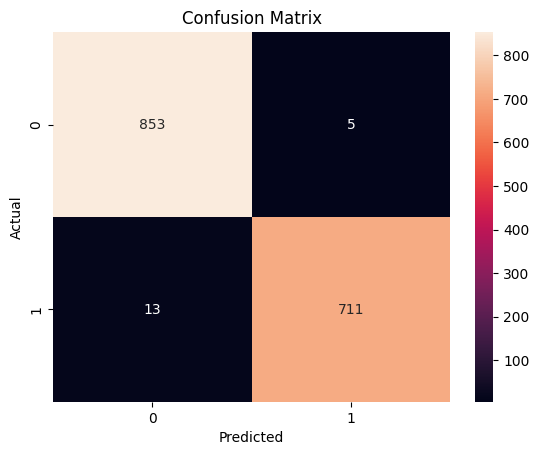

In [87]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

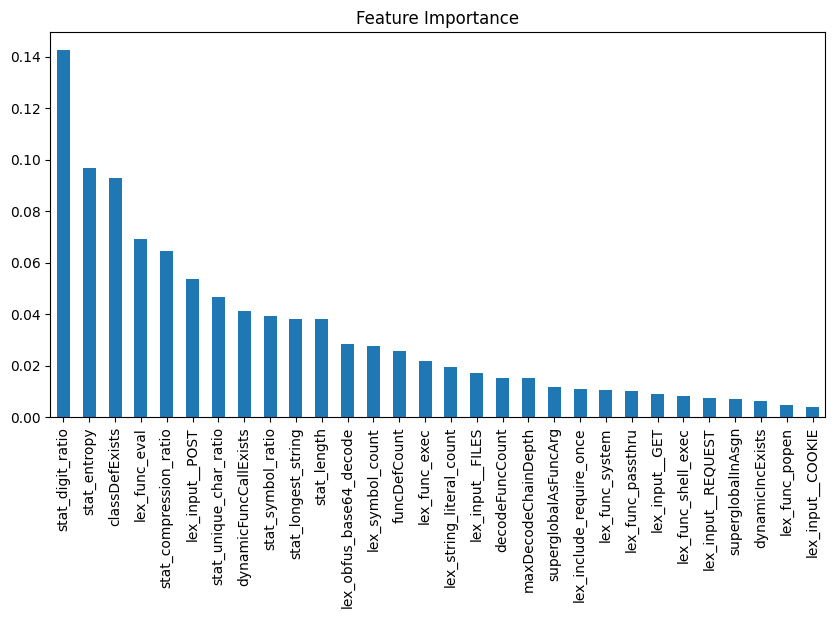

In [88]:
#feature importance 
importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
)

importance.sort_values(ascending=False).head(30).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Feature Importance")
plt.show()

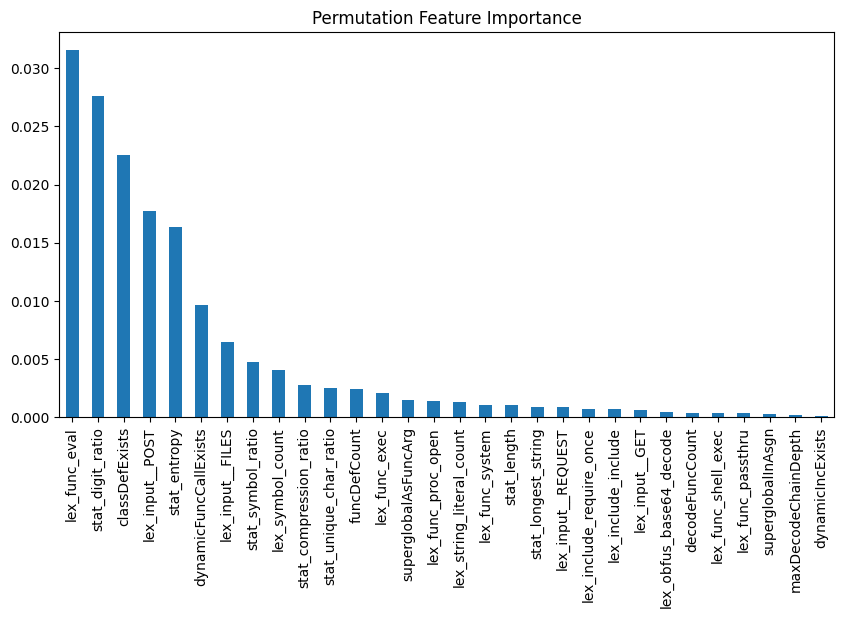

In [89]:
#permutation importance

perm_importance = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42)
perm_importance_df = pd.Series(perm_importance.importances_mean, index=X_test.columns)

perm_importance_df.sort_values(ascending=False).head(30).plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Permutation Feature Importance")
plt.show()

In [90]:
permutation_sorted = perm_importance_df.sort_values(ascending=False)

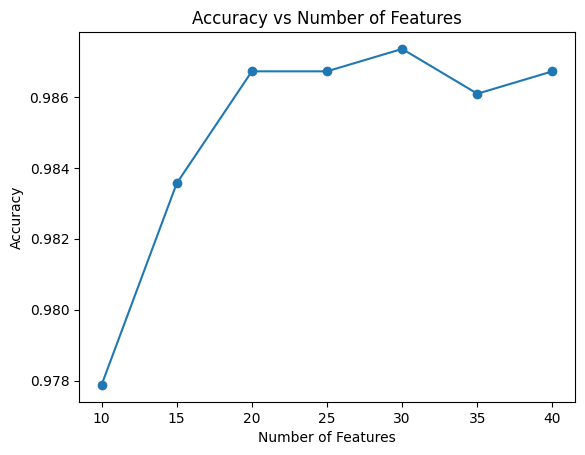

In [91]:
feature_counts = [10, 15, 20, 25, 30, 35, 40]
result = []

for count in feature_counts:
    top_features = permutation_sorted.head(count).index

    X_train_selected = X_train[top_features]
    X_test_selected = X_test[top_features]

    best_rf.fit(X_train_selected, y_train)

    y_pred_selected = best_rf.predict(X_test_selected)

    accuracy = accuracy_score(y_test, y_pred_selected)
    result.append({
        "n_features": count,
        "accuracy": accuracy,
        })


result_df = pd.DataFrame(result)
plt.plot(result_df["n_features"], result_df["accuracy"], marker="o")
plt.title("Accuracy vs Number of Features")
plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.xticks(feature_counts)
plt.show()


In [92]:
features_selected = permutation_sorted.head(25).index
print("Top 25 Fitur Terpenting:", features_selected)

Top 25 Fitur Terpenting: Index(['lex_func_eval', 'stat_digit_ratio', 'classDefExists',
       'lex_input__POST', 'stat_entropy', 'dynamicFuncCallExists',
       'lex_input__FILES', 'stat_symbol_ratio', 'lex_symbol_count',
       'stat_compression_ratio', 'stat_unique_char_ratio', 'funcDefCount',
       'lex_func_exec', 'superglobalAsFuncArg', 'lex_func_proc_open',
       'lex_string_literal_count', 'lex_func_system', 'stat_length',
       'stat_longest_string', 'lex_input__REQUEST', 'lex_include_require_once',
       'lex_include_include', 'lex_input__GET', 'lex_obfus_base64_decode',
       'decodeFuncCount'],
      dtype='object')


In [93]:
X_train_update = X_train[features_selected]
X_test_update = X_test[features_selected]

classifier = RandomForestClassifier(**best_rf.get_params())
classifier.fit(X_train_update, y_train)
y_prob = classifier.predict_proba(X_test_update)[:, 1]

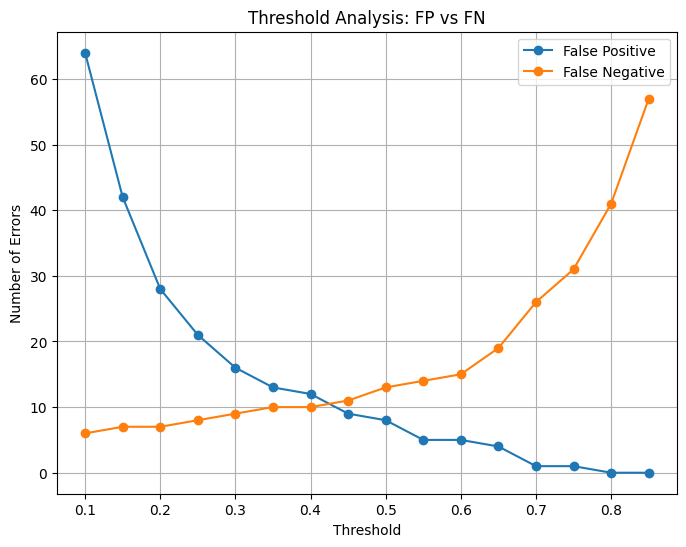

In [94]:
thresholds = np.arange(0.1, 0.9, 0.05)

fp_list = []
fn_list = []

for t in thresholds:

    y_pred = (y_prob >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    fp_list.append(fp)
    fn_list.append(fn)


plt.figure(figsize=(8,6))

plt.plot(thresholds, fp_list, label="False Positive", marker="o")
plt.plot(thresholds, fn_list, label="False Negative", marker="o")

plt.xlabel("Threshold")
plt.ylabel("Number of Errors")

plt.title("Threshold Analysis: FP vs FN")

plt.legend()
plt.grid()

plt.show()

In [95]:
for t in thresholds:
    
    y_pred = (y_prob >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    print(f"Threshold {t:.2f} → FN: {fn}, FP: {fp}")

Threshold 0.10 → FN: 6, FP: 64
Threshold 0.15 → FN: 7, FP: 42
Threshold 0.20 → FN: 7, FP: 28
Threshold 0.25 → FN: 8, FP: 21
Threshold 0.30 → FN: 9, FP: 16
Threshold 0.35 → FN: 10, FP: 13
Threshold 0.40 → FN: 10, FP: 12
Threshold 0.45 → FN: 11, FP: 9
Threshold 0.50 → FN: 13, FP: 8
Threshold 0.55 → FN: 14, FP: 5
Threshold 0.60 → FN: 15, FP: 5
Threshold 0.65 → FN: 19, FP: 4
Threshold 0.70 → FN: 26, FP: 1
Threshold 0.75 → FN: 31, FP: 1
Threshold 0.80 → FN: 41, FP: 0
Threshold 0.85 → FN: 57, FP: 0


In [96]:
threshold = 0.40

y_pred_update = (y_prob >= threshold).astype(int)

accuracy = accuracy_score(y_test, y_pred_update)
classification_rep = classification_report(y_test, y_pred_update)

print(f'Accuracy: {accuracy * 100:.2f}%')
print("\nClassification Report:\n", classification_rep)


Accuracy: 98.61%

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       858
           1       0.98      0.99      0.98       724

    accuracy                           0.99      1582
   macro avg       0.99      0.99      0.99      1582
weighted avg       0.99      0.99      0.99      1582



In [97]:
y_test.shape, y_pred_update.shape, X_test_update.shape, X_train_update.shape, y_train.shape

((1582,), (1582,), (1582, 25), (6325, 25), (6325,))

PR-AUC: 0.9979


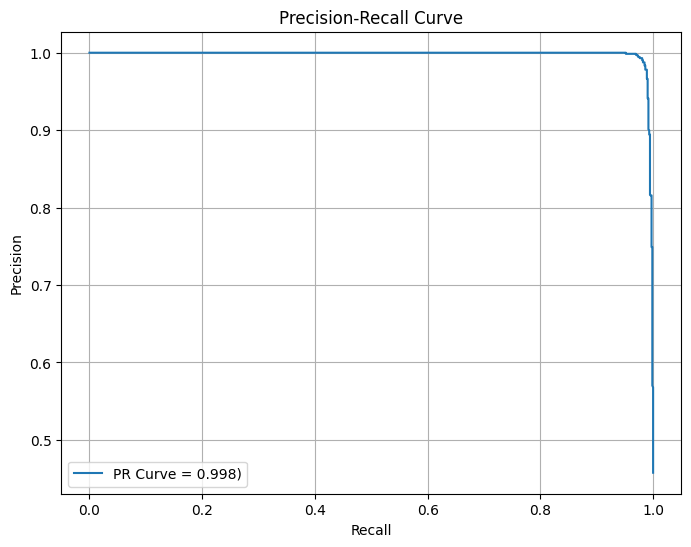

In [98]:
#kurva pr-AUC
from sklearn.metrics import average_precision_score


precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

pr_auc = average_precision_score(y_test, y_prob)
print(f"PR-AUC: {pr_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

ROC-AUC: 0.9976


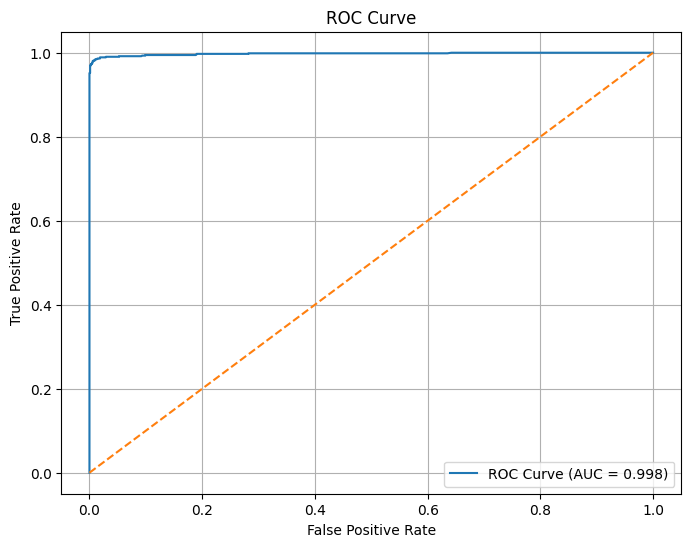

In [99]:
#ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot ([0, 1], [0, 1], linestyle="--")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show() 


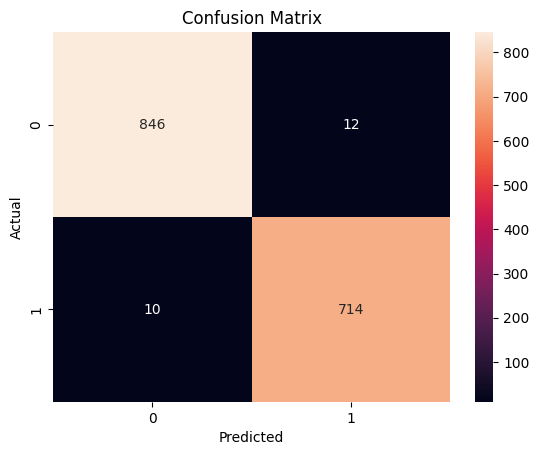

In [100]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred_update)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [101]:
results = X_test_update.copy()
results["actual"] = y_test
results["predicted"] = y_pred_update

false_positive = results[(results["actual"] == 0) & (results["predicted"] == 1)]

print("Jumlah False Positive:", len(false_positive))
false_positive.to_csv("false_positive.csv", index=False)

Jumlah False Positive: 12


In [102]:
false_negative = results[(results["actual"] == 1) & (results["predicted"] == 0)]

print("Jumlah False Negative:", len(false_negative))
false_negative.to_csv("false_negative.csv", index=False)

Jumlah False Negative: 10


In [103]:
train_acc = classifier.score(X_train_update, y_train)
test_acc = classifier.score(X_test_update, y_test)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Train accuracy: 0.9998418972332016
Test accuracy: 0.9867256637168141


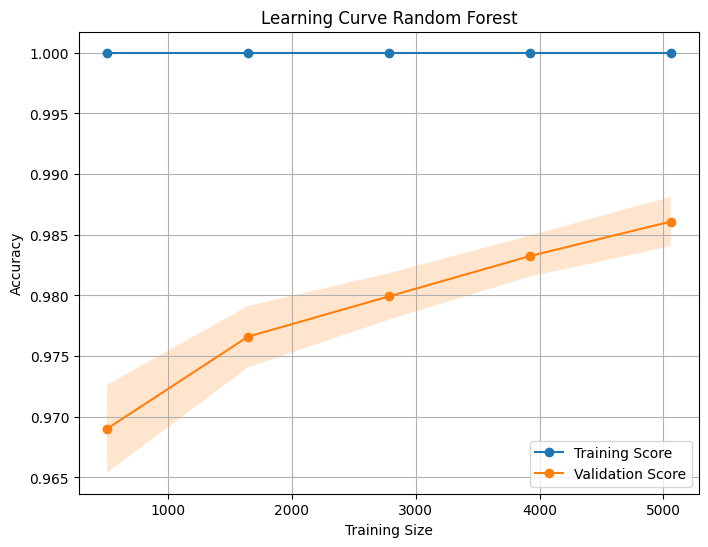

In [104]:
#learning curve
train_sizes, train_scores, test_scores = learning_curve(
    classifier,
    X_train_update,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

train_std = np.std(train_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label="Training Score", marker="o")
plt.plot(train_sizes, test_mean, label="Validation Score", marker="o")

plt.fill_between(train_sizes,
                 train_mean-train_std,
                 train_mean+train_std,
                 alpha=0.2)

plt.fill_between(train_sizes,
                 test_mean-test_std,
                 test_mean+test_std,
                 alpha=0.2)

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve Random Forest")

plt.legend()
plt.grid()

plt.show()



Cross-validation scores: [0.98339921 0.98656126 0.98339921 0.98735178 0.98893281]
Mean cross-validation score: 0.9859288537549407
Standard Deviation of cross-validation scores: 0.002202116723665461


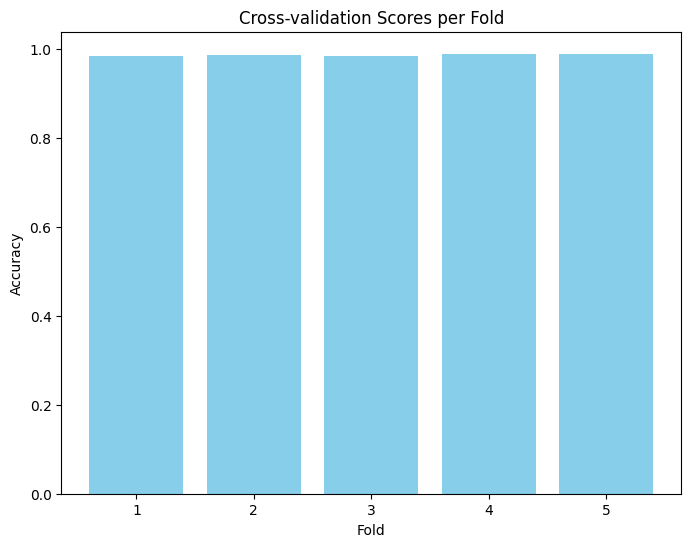

In [105]:
#cross validation

scores_val = cross_val_score(classifier, X_train_update, y_train, cv=5, scoring="accuracy")
print("Cross-validation scores:", scores_val)
print("Mean cross-validation score:", scores_val.mean())
print("Standard Deviation of cross-validation scores:", scores_val.std())

folds = np.arange(1, len(scores_val) + 1)

plt.figure(figsize=(8,6))
plt.bar(folds, scores_val, color="skyblue")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross-validation Scores per Fold")
plt.show()

In [107]:
joblib.dump(classifier, "rf_webshell_model.pkl")

['rf_webshell_model.pkl']

In [108]:
joblib.dump(features_selected, "features_selected.pkl")

['features_selected.pkl']